In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%config InlineBackend.figure_format = 'svg'

In [2]:
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'lines.linewidth': 2})

# Benchmark of EH Self Acceleration

In [3]:
L = 60 * np.pi
nx = 4000
dx = L / (nx - 1)

vmax_e = 10  # 速度最大值
nv_e = 2000
dv_e = 2 * vmax_e / (nv_e - 1)

vmax_i = 0.52185  # 速度最大值
nv_i = 2000
dv_i = 2 * vmax_i / (nv_i - 1)

x = np.linspace(0, L, num=nx, endpoint=True)
ve = np.linspace(-vmax_e, vmax_e, num=nv_e, endpoint=True)
vi = np.linspace(-vmax_i, vmax_i, num=nv_i, endpoint=True)
Ve, Xe = np.meshgrid(ve, x)
Vi, Xi = np.meshgrid(vi, x)

dt = 0.05
max_steps = 20000
data_steps = int(max_steps / 1)
data_num = int(max_steps / data_steps) + 1

path = r"E:\工作\我的论文\2026CHSinAppliedEField\simulations\self_acceleration"

print(data_num)
print("real time = ", max_steps * dt)

2
real time =  1000.0


In [4]:
phi = np.loadtxt(os.path.join(path, "Phi_evolution"))
t = np.linspace(0, max_steps, num = max_steps + 1, endpoint=True) * dt

In [5]:
fi0 = np.loadtxt(os.path.join(path,"fi0"))

In [6]:
psi = 0.1
mi = 1836
vi_r = np.sqrt(2 * psi / mi)
print("vi_r = ", vi_r)

vi_r =  0.010437071518085825


In [7]:
phi_peaks_x = np.argmax(phi, axis=0) * dx

v_fit_start = 12000
v_fit_end = 19001
phi_peaks_x_fit = phi_peaks_x[v_fit_start:v_fit_end]
t_fit = t[v_fit_start:v_fit_end]
velocity_fit, _ = np.polyfit(t_fit, phi_peaks_x_fit, 1)
print("Fitted velocity:", velocity_fit)

Fitted velocity: 0.09280767512480415


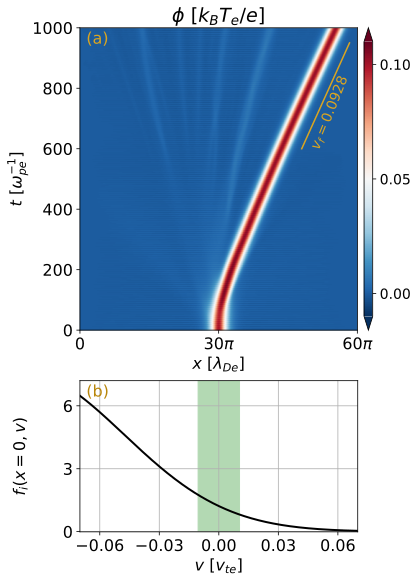

In [ ]:
T, X = np.meshgrid(t, x)
vi_ticks = [-0.06, -0.03, 0.0, 0.03, 0.06]
fi_ticks = [0.0, 3, 6]

fig, (ax1,ax2) = plt.subplots(figsize=(6, 9), nrows=2, ncols=1, height_ratios=[2, 1])

# fig = plt.figure(figsize=(6, 6))
cb = ax1.pcolormesh(X, T, phi, vmin=-0.01, vmax=0.11, cmap=cm.RdBu_r, rasterized=True)
ax1.plot(
    velocity_fit * t_fit + 95,
    t_fit,
    color="goldenrod",
    linestyle="-",
    linewidth=1.5,
    label="Fitted line",
)
ax1.text(
    velocity_fit * t_fit[0] + 100,
    t_fit[0],
    r"$v_{f} = $" + f"{velocity_fit:.4f}",
    color="goldenrod",
    fontsize=14,
    rotation=68.2,
)
ax1.set_xlabel(r"$x~[\lambda_{De}]$")
ax1.set_ylabel(r"$t~[\omega_{pe}^{-1}]$")
ax1.set_xticks([0, 30 * np.pi, 60 * np.pi], ["0", r"$30\pi$", r"$60\pi$"])
cbar = plt.colorbar(cb, ticks=[0.0, 0.05, 0.1], extend="both", aspect=35, pad=0.02)
cbar.ax.tick_params(labelsize=14)
ax1.set_title(r"$\phi~[k_B T_e/e]$")

ax2.plot(vi, fi0[0, :], linestyle="-", color="black", label="initial")
ax2.axvspan(-vi_r, vi_r, alpha=0.3, color="green")
ax2.set_xlim(-0.07, +0.07)
ax2.set_ylim(-0.01, +7.2)
ax2.set_xlabel(r"$v ~[v_{te}]$")
ax2.set_ylabel(r"$f_i(x=0, v)$")
ax2.set_xticks(vi_ticks)
ax2.set_yticks(fi_ticks)
ax2.grid()

ax1.text(0.023, 0.9475, "(a)", transform=ax1.transAxes, color="goldenrod")
ax2.text(0.023, 0.895, "(b)", transform=ax2.transAxes, color="darkgoldenrod")

ax2pos = ax2.get_position()
ax2.set_position([ax2pos.x0, ax2pos.y0-0.008, ax2pos.width*0.831, ax2pos.height]) 

fig.align_ylabels()

# plt.savefig("./fig2_phi_evo_benchmark.pdf", bbox_inches='tight', dpi = 600)
plt.show()

In [9]:
print(phi_peaks_x_fit[0], phi_peaks_x_fit[-1], t_fit[0], t_fit[-1])
print((phi_peaks_x_fit[-1] - phi_peaks_x_fit[0]) / (t_fit[-1] - t_fit[0]))

136.88199648949376 169.31134001042065 600.0 950.0
0.09265526720264826
